## Keras: Building and Training Neural Net

In [23]:
# import necc libs

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
# deep learning libs
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization
from keras.optimizers import SGD, Adam, RMSprop

In [3]:
names = ["times_pregnant", "glucose_tolerance_test", "blood_pressure", "skin_thickness", "insulin", 
         "bmi", "pedigree_function", "age", "has_diabetes"]
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module2/L2/diabetes.csv", names=names, header=0)

## Data Inspection

In [4]:
df.head()

,times_pregnant,glucose_tolerance_test,blood_pressure,skin_thickness,insulin,bmi,pedigree_function,age,has_diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.shape

(768, 9)

<Axes: xlabel='has_diabetes'>

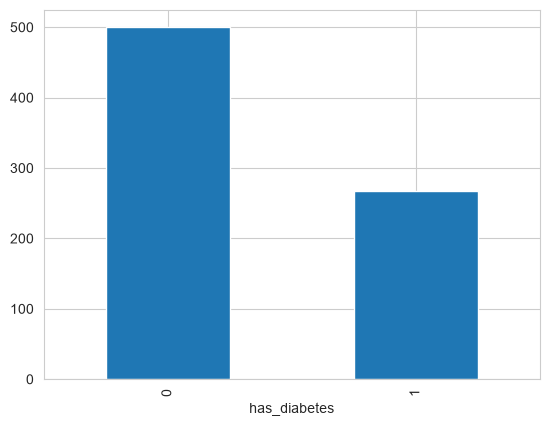

In [16]:
sns.set_style('whitegrid')
df.has_diabetes.value_counts().plot(kind='bar')

In [13]:
X = df.drop(columns='has_diabetes').values
y = df['has_diabetes'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_loc, test_loc = next(skf.split(X, y))
scaler = StandardScaler()

X_train = X[train_loc]
X_test = X[test_loc]

y_train = y[train_loc]
y_test = y[test_loc]

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

np.mean(y), np.mean(1-y)

(np.float64(0.3489583333333333), np.float64(0.6510416666666666))

## Baseline Performance using Random Forests

In [20]:
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)
rf_predict = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)

accuracy = accuracy_score(y_test, rf_predict)
roc_score = roc_auc_score(y_test, rf_proba[:,1])

print(f"Accuracy: {accuracy:.3f}  |  ROC Score: {roc_score:.3f}")

Accuracy: 0.792  |  ROC Score: 0.847


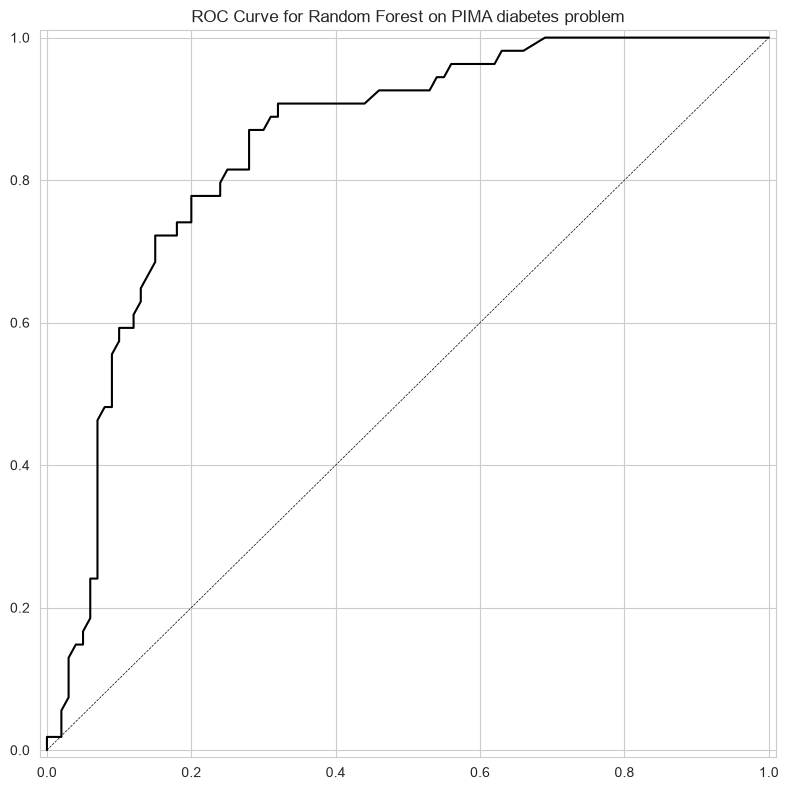

In [24]:
def plot_roc(y_test, y_pred, model_name: str):
    fpr, tpr, thr = roc_curve(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(fpr, tpr, 'k-')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=.5)
    ax.grid(True)
    ax.set(title='ROC Curve for {} on PIMA diabetes problem'.format(model_name),
               xlim=[-0.01, 1.01], ylim=[-0.01, 1.01])
    plt.tight_layout()

plot_roc(y_test, rf_proba[:,1], 'Random Forest')

## Build a Single Hidden Layer Neural Network

We will use the Sequential model to quickly build a neural network.  Our first network will be a single layer network.  We have 8 variables, so we set the input shape to 8.  Let's start by having a single hidden layer with 12 nodes.

In [25]:
model_1 = Sequential()
model_1.add(Dense(12, input_shape=(8,), activation='sigmoid'))
model_1.add(Dense(1,activation='sigmoid'))

model_1.summary()

c:\Users\LEI\Documents\deep-learning-ibm\.venv\Lib\site-packages\keras\src\layers\core\dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
# FIT(TRAIN) the model
model_1.compile(SGD(learning_rate=.003), "binary_crossentropy", metrics=['accuracy'])
run_hist_1 = model_1.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=200)

y_prob_nn = model_1.predict(X_test).ravel()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7524 - loss: 0.4900 - val_accuracy: 0.7143 - val_loss: 0.5033
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7524 - loss: 0.4899 - val_accuracy: 0.7143 - val_loss: 0.5033
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7524 - loss: 0.4897 - val_accuracy: 0.7143 - val_loss: 0.5032
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7524 - loss: 0.4896 - val_accuracy: 0.7143 - val_loss: 0.5031
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7524 - loss: 0.4895 - val_accuracy: 0.7143 - val_loss: 0.5030
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7524 - loss: 0.4893 - val_accuracy: 0.7143 - val_loss: 0.5029
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7524 - loss: 0.4892 - val_accuracy: 0.7143 - val_loss: 0.5028
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7524 - loss: 0.4891 - val_accuracy: 0.7143 - 

In [27]:
y_pred_nn[:10]

array([[0.4657193 ],
       [0.5495869 ],
       [0.36083966],
       [0.5121832 ],
       [0.46820527],
       [0.21551003],
       [0.6288094 ],
       [0.5033814 ],
       [0.4410427 ],
       [0.31953198]], dtype=float32)

In [28]:
y_prob_nn[:10]

array([[0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0]])

Accuracy: 0.734  |  ROC Score: 0.819


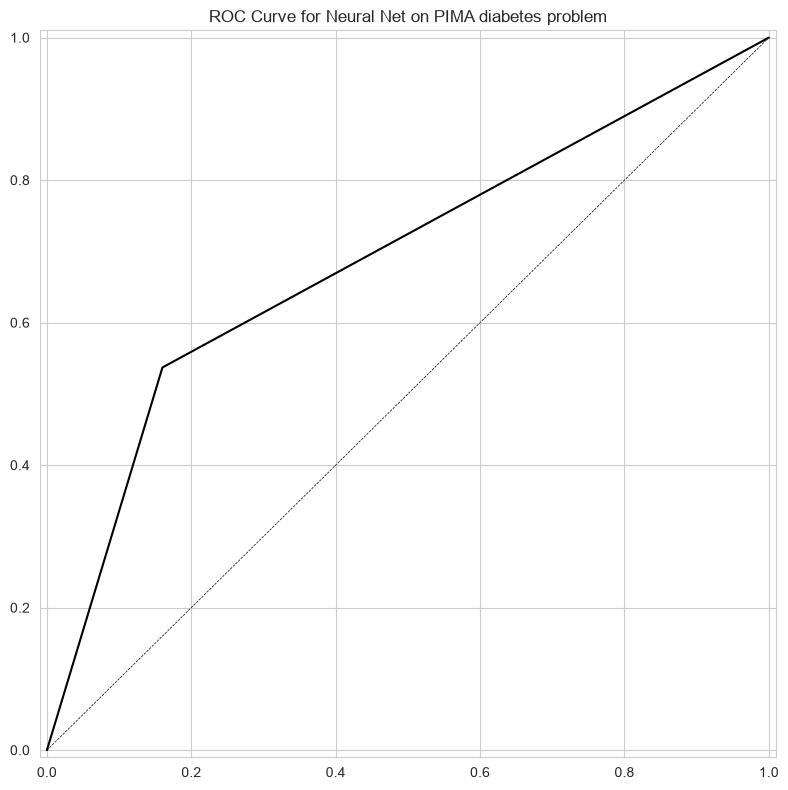

In [33]:
# print model accuracy and roc score
nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_roc_score = roc_auc_score(y_test, y_prob_nn)

print(f"Accuracy: {nn_accuracy:.3f}  |  ROC Score: {nn_roc_score:.3f}")
plot_roc(y_test, y_pred_nn, 'Neural Net')

In [35]:
run_hist_1.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

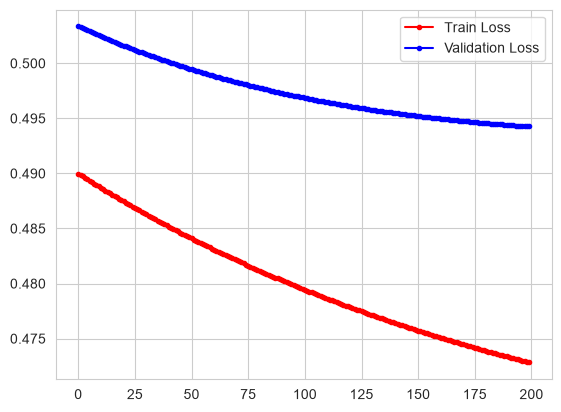

In [36]:
fig, ax = plt.subplots()
ax.plot(run_hist_1.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(run_hist_1.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.legend()

Epoch 1/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7687 - loss: 0.4728 - val_accuracy: 0.7338 - val_loss: 0.4942
Epoch 2/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7687 - loss: 0.4727 - val_accuracy: 0.7338 - val_loss: 0.4942
Epoch 3/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7704 - loss: 0.4727 - val_accuracy: 0.7338 - val_loss: 0.4942
Epoch 4/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7687 - loss: 0.4726 - val_accuracy: 0.7338 - val_loss: 0.4942
Epoch 5/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7687 - loss: 0.4726 - val_accuracy: 0.7338 - val_loss: 0.4942
Epoch 6/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7687 - loss: 0.4725 - val_accuracy: 0.7338 - val_loss: 0.4942
Epoch 7/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7687 - loss: 0.4725 - val_accuracy: 0.7338 - val_loss: 0.4942
Epoch 8/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7687 - loss: 0.4724 - val_accuracy: 0.

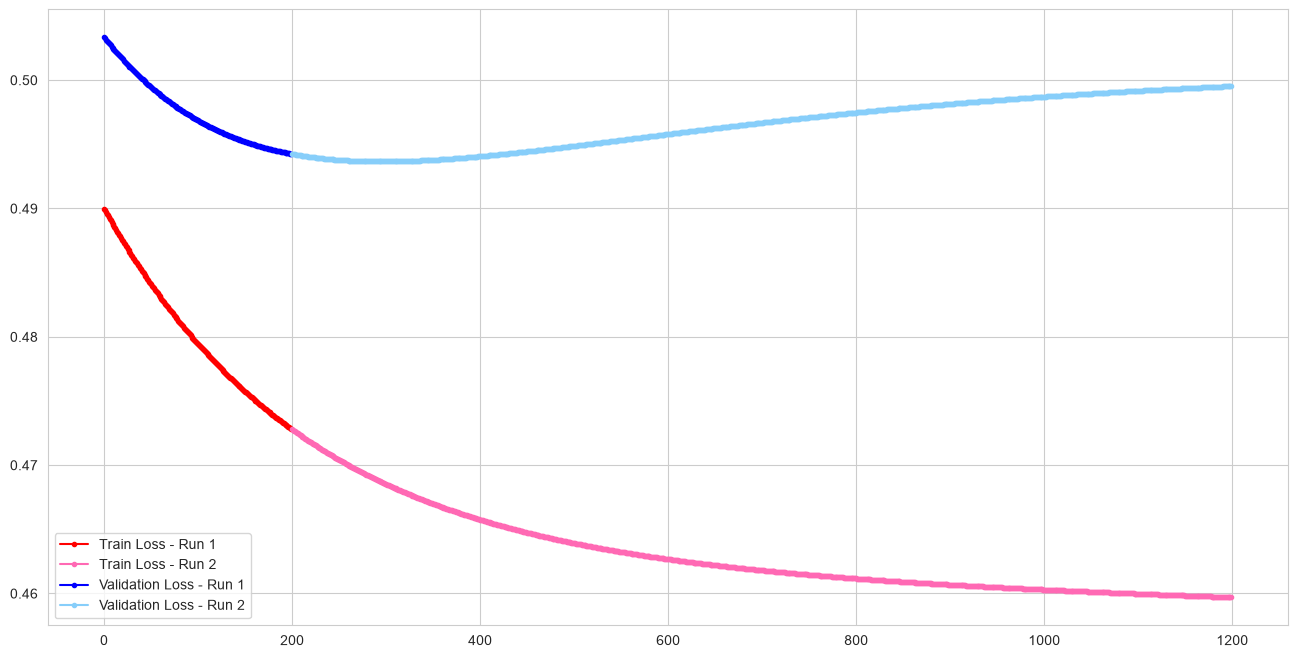

In [37]:
run_hist_1b = model_1.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1000)
n = len(run_hist_1.history["loss"])
m = len(run_hist_1b.history['loss'])
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(range(n), run_hist_1.history["loss"],'r', marker='.', label="Train Loss - Run 1")
ax.plot(range(n, n+m), run_hist_1b.history["loss"], 'hotpink', marker='.', label="Train Loss - Run 2")

ax.plot(range(n), run_hist_1.history["val_loss"],'b', marker='.', label="Validation Loss - Run 1")
ax.plot(range(n, n+m), run_hist_1b.history["val_loss"], 'LightSkyBlue', marker='.',  label="Validation Loss - Run 2")

ax.legend()

## Exercise 2
For this exercise, do the following in the cells below:
- Build a model with two hidden layers, each with 6 nodes
- Use the "relu" activation function for the hidden layers, and "sigmoid" for the final layer
- Use a learning rate of .003 and train for 1500 epochs
- Graph the trajectory of the loss functions, accuracy on both train and test set
- Plot the roc curve for the predictions

Experiment with different learning rates, numbers of epochs, and network structures

Epoch 1/1000


c:\Users\LEI\Documents\deep-learning-ibm\.venv\Lib\site-packages\keras\src\layers\core\dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5977 - loss: 0.6677 - val_accuracy: 0.6234 - val_loss: 0.6714
Epoch 2/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5993 - loss: 0.6658 - val_accuracy: 0.6299 - val_loss: 0.6697
Epoch 3/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5993 - loss: 0.6640 - val_accuracy: 0.6429 - val_loss: 0.6679
Epoch 4/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6010 - loss: 0.6621 - val_accuracy: 0.6429 - val_loss: 0.6662
Epoch 5/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6010 - loss: 0.6603 - val_accuracy: 0.6494 - val_loss: 0.6645
Epoch 6/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6042 - loss: 0.6585 - val_accuracy: 0.6494 - val_loss: 0.6629
Epoch 7/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6059 - loss: 0.6568 - val_accuracy: 0.6623 - val_loss: 0.6613
Epoch 8/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6124 - loss: 0.6550 - val_accuracy: 0.6623 - val_l

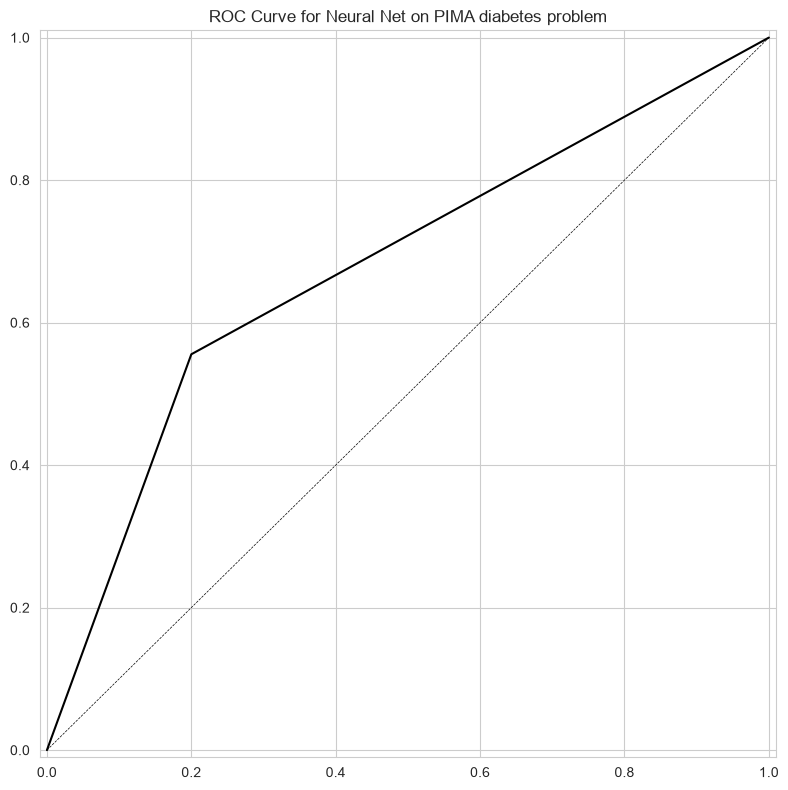

In [41]:
model_2 = Sequential()

model_2.add(Dense(6, input_shape=(8,), activation='relu'))
model_2.add(Dense(6, activation='relu'))
model_2.add(Dense(1, activation='sigmoid'))
model_2.compile(SGD(learning_rate=.003), 'binary_crossentropy', metrics=['accuracy'])

run_hist_2 = model_2.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1000)

y_prob = model_2.predict(X_test).ravel()
y_pred = (y_prob > .5).astype(int)

model_2_acc = accuracy_score(y_test, y_pred)
model_2_roc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {model_2_acc:.3f}  |  ROC Score: {model_2_roc:.3f}")
plot_roc(y_test, y_pred, 'Neural Net')

In [42]:
run_hist_2.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

Text(0.5, 1.0, 'Accuracy over iterations')

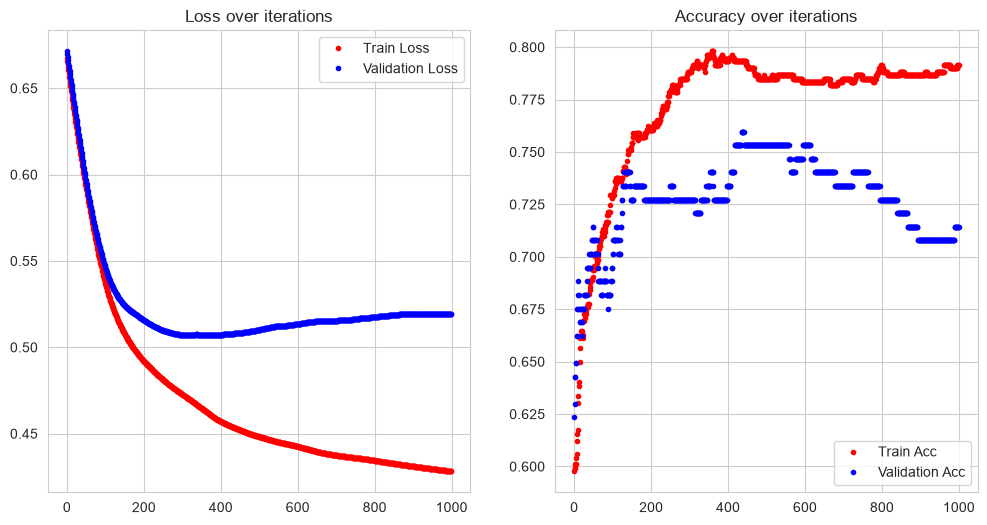

In [45]:
n = len(run_hist_2.history["loss"])

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 2, 1)
ax.plot(range(n), (run_hist_2.history["loss"]),'r.', label="Train Loss")
ax.plot(range(n), (run_hist_2.history["val_loss"]),'b.', label="Validation Loss")
ax.legend()
ax.set_title('Loss over iterations')

ax = fig.add_subplot(1, 2, 2)
ax.plot(range(n), (run_hist_2.history["accuracy"]),'r.', label="Train Acc")
ax.plot(range(n), (run_hist_2.history["val_accuracy"]),'b.', label="Validation Acc")
ax.legend(loc='lower right')
ax.set_title('Accuracy over iterations')

## Summary

In [46]:
model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (424.00 B)

 Trainable params: 103 (412.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)